In [ ]:
import pandas as pd


In [ ]:
ball_by_ball_df = pd.read_csv('/content/IPL_ball_by_ball_updated.csv')

In [ ]:
ball_by_ball_df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Shape Analysis**

In [ ]:
number_of_records, number_of_features = ball_by_ball_df.shape

**Missing values**

In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['wides'].unique()

array([nan,  1.,  5.,  2.,  3.,  4.])

| `wides` value | What happened                            |
| ------------- | ---------------------------------------- |
| `NaN` / `0`   | Normal legal delivery                    |
| `1`           | Standard wide (1 penalty run)            |
| `2`           | Wide + batters ran 1                     |
| `3`           | Wide + batters ran 2                     |
| `4`           | Wide + boundary                          |
| `5`           | Rare case (wide + boundary + overthrows) |


In [ ]:
ball_by_ball_df["wides"] = ball_by_ball_df["wides"].fillna(0)

In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['noballs'].unique()

array([0, 1, 5, 2, 3])

| `noballs` value | What happened               |
| --------------- | --------------------------- |
| `NaN`           | Normal legal delivery       |
| `1`             | No-ball only (no bat runs)  |
| `2`             | No-ball + 1 run off the bat |
| `3`             | No-ball + 2 bat runs        |
| `5`             | No-ball + boundary (4)      |


In [ ]:
ball_by_ball_df["noballs"] = ball_by_ball_df["noballs"].fillna(0).astype(int)

In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['byes'].unique()

array([nan,  4.,  1.,  2.,  3.])

In [ ]:
ball_by_ball_df["byes"] = ball_by_ball_df["byes"].fillna(0).astype(int)


In [ ]:
ball_by_ball_df.nunique()

,0
match_id,1024
season,16
start_date,762
venue,54
innings,6
ball,182
batting_team,18
bowling_team,18
striker,637
non_striker,626


In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['legbyes'].unique()

array([ 1., nan,  4.,  2.,  3.,  5.])

In [ ]:
ball_by_ball_df["legbyes"] = ball_by_ball_df["legbyes"].fillna(0).astype(int)

In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['penalty'].unique()

array([nan,  5.])

In [ ]:
ball_by_ball_df["penalty"] = ball_by_ball_df["penalty"].fillna(0).astype(int)


In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


Data Processing & Feature Engineering

In [ ]:
ball_by_ball_df['wicket_type'].unique()

array([nan, 'caught', 'bowled', 'run out', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

In [ ]:
ball_by_ball_df["is_wicket"] = (
    ball_by_ball_df["wicket_type"].notna().astype(int)
)


In [ ]:
bowler_wickets = [
    "caught", "bowled", "lbw", "stumped",
    "caught and bowled", "hit wicket"
]

ball_by_ball_df["is_bowler_wicket"] = (
    ball_by_ball_df["wicket_type"].isin(bowler_wickets)
)

In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['is_bowler_wicket'].unique()

array([False,  True])

In [ ]:
bowler_wickets = [
    "caught", "bowled", "lbw", "stumped",
    "caught and bowled", "hit wicket"
]

# Column for bowler wickets only (empty string if not bowler wicket)
ball_by_ball_df["bowler_wicket_type"] = ball_by_ball_df["wicket_type"].where(
    ball_by_ball_df["wicket_type"].isin(bowler_wickets)
).fillna("")

# Column for non-bowler wickets only (empty string if bowler wicket)
ball_by_ball_df["not_bowler_wicket_type"] = ball_by_ball_df["wicket_type"].where(
    ~ball_by_ball_df["wicket_type"].isin(bowler_wickets) & ball_by_ball_df["wicket_type"].notna()
).fillna("")


In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [ ]:
ball_by_ball_df['bowler_wicket_type'].unique()

array(['', 'caught', 'bowled', 'lbw', 'stumped', 'caught and bowled',
       'hit wicket'], dtype=object)

In [ ]:
ball_by_ball_df['not_bowler_wicket_type'].unique()

array(['', 'run out', 'retired hurt', 'obstructing the field',
       'retired out'], dtype=object)

In [ ]:
ball_by_ball_df['is_wicket'].unique()

array([0, 1])

In [ ]:
ball_by_ball_df['is_bowler_wicket'].unique()

array([False,  True])

In [ ]:
ball_by_ball_df['player_dismissed'].unique()

array([nan, 'SC Ganguly', 'RT Ponting', 'DJ Hussey', 'R Dravid',
       'V Kohli', 'JH Kallis', 'W Jaffer', 'MV Boucher', 'B Akhil',
       'CL White', 'AA Noffke', 'Z Khan', 'SB Joshi', 'PA Patel',
       'ML Hayden', 'MS Dhoni', 'SK Raina', 'JDP Oram', 'K Goel',
       'JR Hopes', 'Yuvraj Singh', 'KC Sangakkara', 'T Kohli',
       'YK Pathan', 'SR Watson', 'DS Lehmann', 'M Kaif', 'M Rawat',
       'RA Jadeja', 'SK Warne', 'V Sehwag', 'L Ronchi', 'DJ Thornely',
       'ST Jayasuriya', 'PR Shah', 'RV Uthappa', 'AM Nayar', 'SM Pollock',
       'S Chanderpaul', 'LRPL Taylor', 'Y Venugopal Rao', 'VVS Laxman',
       'AC Gilchrist', 'RG Sharma', 'SB Styris', 'AS Yadav', 'A Symonds',
       'WPUJC Vaas', 'SB Bangar', 'PP Ojha', 'BB McCullum', 'WP Saha',
       'Mohammad Hafeez', 'DPMD Jayawardene', 'IK Pathan', 'B Lee',
       'S Sohal', 'Kamran Akmal', 'Shahid Afridi', 'G Gambhir',
       'MEK Hussey', 'DJ Bravo', 'MA Khote', 'Harbhajan Singh',
       'GC Smith', 'D Salunkhe', 'RR Sarwan',

In [ ]:
ball_by_ball_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243815 non-null  int64  
 1   season                  243815 non-null  int64  
 2   start_date              243815 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 243815 non-null  int64  
 5   ball                    243815 non-null  float64
 6   batting_team            243815 non-null  object 
 7   bowling_team            243815 non-null  object 
 8   striker                 243815 non-null  object 
 9   non_striker             243815 non-null  object 
 10  bowler                  243815 non-null  object 
 11  runs_off_bat            243815 non-null  int64  
 12  extras                  243815 non-null  int64  
 13  wides                   243815 non-null  float64
 14  noballs             

In [ ]:
# Player dismissed credited to bowler
ball_by_ball_df["bowler_wicket_player"] = ball_by_ball_df["player_dismissed"].where(
    ball_by_ball_df["wicket_type"].isin(bowler_wickets)
).fillna("")

# Player dismissed NOT credited to bowler
ball_by_ball_df["not_bowler_wicket_player"] = ball_by_ball_df["player_dismissed"].where(
    ~ball_by_ball_df["wicket_type"].isin(bowler_wickets) & ball_by_ball_df["wicket_type"].notna()
).fillna("")


In [ ]:
ball_by_ball_df.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


Removing the columns which have empty records

In [ ]:

non_empty_cols = ball_by_ball_df.columns[ball_by_ball_df.notna().any()]
ball_by_ball_df_non_empty = ball_by_ball_df[non_empty_cols]
ball_by_ball_df_non_empty = ball_by_ball_df_non_empty.drop(columns=["wicket_type", "player_dismissed"])



In [ ]:
ball_by_ball_df_non_empty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   match_id                  243815 non-null  int64  
 1   season                    243815 non-null  int64  
 2   start_date                243815 non-null  object 
 3   venue                     243815 non-null  object 
 4   innings                   243815 non-null  int64  
 5   ball                      243815 non-null  float64
 6   batting_team              243815 non-null  object 
 7   bowling_team              243815 non-null  object 
 8   striker                   243815 non-null  object 
 9   non_striker               243815 non-null  object 
 10  bowler                    243815 non-null  object 
 11  runs_off_bat              243815 non-null  int64  
 12  extras                    243815 non-null  int64  
 13  wides                     243815 non-null  f

In [ ]:
ball_by_ball_df_non_empty.to_csv("non_missing_value.csv")

In [ ]:
df = ball_by_ball_df_non_empty.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   match_id                  243815 non-null  int64  
 1   season                    243815 non-null  int64  
 2   start_date                243815 non-null  object 
 3   venue                     243815 non-null  object 
 4   innings                   243815 non-null  int64  
 5   ball                      243815 non-null  float64
 6   batting_team              243815 non-null  object 
 7   bowling_team              243815 non-null  object 
 8   striker                   243815 non-null  object 
 9   non_striker               243815 non-null  object 
 10  bowler                    243815 non-null  object 
 11  runs_off_bat              243815 non-null  int64  
 12  extras                    243815 non-null  int64  
 13  wides                     243815 non-null  f

In [ ]:
# def classify_wicket(x):
#     if pd.isna(x):
#         return "no_wicket"
#     elif x in bowler_wickets:
#         return "bowler_wicket"
#     else:
#         return "not_bowler_wicket"

# ball_by_ball_df["wicket_type_class"] = ball_by_ball_df["wicket_type"].apply(classify_wicket)


**Splitting the data by dtype**

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   match_id                  243815 non-null  int64  
 1   season                    243815 non-null  int64  
 2   start_date                243815 non-null  object 
 3   venue                     243815 non-null  object 
 4   innings                   243815 non-null  int64  
 5   ball                      243815 non-null  float64
 6   batting_team              243815 non-null  object 
 7   bowling_team              243815 non-null  object 
 8   striker                   243815 non-null  object 
 9   non_striker               243815 non-null  object 
 10  bowler                    243815 non-null  object 
 11  runs_off_bat              243815 non-null  int64  
 12  extras                    243815 non-null  int64  
 13  wides                     243815 non-null  f

In [ ]:
processable_data = df.select_dtypes(include=['float64','int64','bool'])

In [ ]:
processable_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          243815 non-null  int64  
 1   season            243815 non-null  int64  
 2   innings           243815 non-null  int64  
 3   ball              243815 non-null  float64
 4   runs_off_bat      243815 non-null  int64  
 5   extras            243815 non-null  int64  
 6   wides             243815 non-null  float64
 7   noballs           243815 non-null  int64  
 8   byes              243815 non-null  int64  
 9   legbyes           243815 non-null  int64  
 10  penalty           243815 non-null  int64  
 11  is_wicket         243815 non-null  int64  
 12  is_bowler_wicket  243815 non-null  bool   
dtypes: bool(1), float64(2), int64(10)
memory usage: 22.6 MB


In [ ]:
unprocessable_data = df.select_dtypes(include=['object'])

In [ ]:
unprocessable_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   start_date                243815 non-null  object
 1   venue                     243815 non-null  object
 2   batting_team              243815 non-null  object
 3   bowling_team              243815 non-null  object
 4   striker                   243815 non-null  object
 5   non_striker               243815 non-null  object
 6   bowler                    243815 non-null  object
 7   bowler_wicket_type        243815 non-null  object
 8   not_bowler_wicket_type    243815 non-null  object
 9   bowler_wicket_player      243815 non-null  object
 10  not_bowler_wicket_player  243815 non-null  object
dtypes: object(11)
memory usage: 20.5+ MB


In [ ]:
unprocessable_data.head()

,start_date,venue,batting_team,bowling_team,striker,non_striker,bowler,bowler_wicket_type,not_bowler_wicket_type,bowler_wicket_player,not_bowler_wicket_player
0,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,,,,
1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,,,,
2,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,,,,
3,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,,,,
4,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,,,,


In [ ]:
unprocessable_data['start_date'] = pd.to_datetime(unprocessable_data['start_date'])

In [ ]:
unprocessable_data["year"] = unprocessable_data["start_date"].dt.year
unprocessable_data["month"] = unprocessable_data["start_date"].dt.month
unprocessable_data["date"] = unprocessable_data["start_date"].dt.day


In [ ]:
unprocessable_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   start_date                243815 non-null  datetime64[ns]
 1   venue                     243815 non-null  object        
 2   batting_team              243815 non-null  object        
 3   bowling_team              243815 non-null  object        
 4   striker                   243815 non-null  object        
 5   non_striker               243815 non-null  object        
 6   bowler                    243815 non-null  object        
 7   bowler_wicket_type        243815 non-null  object        
 8   not_bowler_wicket_type    243815 non-null  object        
 9   bowler_wicket_player      243815 non-null  object        
 10  not_bowler_wicket_player  243815 non-null  object        
 11  year                      243815 non-null  int32         
 12  mo

In [ ]:
unprocessable_data["start_date"] = pd.to_datetime(unprocessable_data["start_date"])

In [ ]:
unprocessable_data.head()

,start_date,venue,batting_team,bowling_team,striker,non_striker,bowler,wicket_type,player_dismissed
0,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,NaN,NaN
1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN
2,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN
3,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN
4,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,NaN,NaN


In [ ]:
unprocessable_data['venue'].nunique()

54

In [ ]:
unprocessable_data['venue'].nunique()

38

In [ ]:
unprocessable_data['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association IS Bindra Stadium, Mohali',
       'Arun Jaitley Stadium, Delhi', 'Wankhede Stadium, Mumbai',
       'Eden Gardens, Kolkata', 'Sawai Mansingh Stadium, Jaipur',
       'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
       'MA Chidambaram Stadium, Chepauk, Chennai',
       'Dr DY Patil Sports Academy, Mumbai', 'Newlands',
       "St George's Park", 'Kingsmead', 'SuperSport Park', 'Buffalo Park',
       'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium, Mumbai',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium, Dharamsala',
       'Nehru Stadium', 'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium, Pune',
       'Shaheed Veer Narayan 

In [ ]:
# Example mapping
venue_mapping = {
    # Punjab Cricket Association IS Bindra Stadium variants (all Mohali, Punjab)
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association IS Bindra Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association IS Bindra Stadium, Mohali",

    # Sawai Mansingh Stadium variants (all Jaipur, Rajasthan)
    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium, Jaipur",

    # Rajiv Gandhi International Stadium variants (all Uppal, Hyderabad)
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",

    # MA Chidambaram Stadium variants (all Chepauk, Chennai)
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium, Chepauk, Chennai",

    # Wankhede Stadium variants
    "Wankhede Stadium": "Wankhede Stadium, Mumbai",
    "Wankhede Stadium, Mumbai": "Wankhede Stadium, Mumbai",

    # Eden Gardens variants
    "Eden Gardens": "Eden Gardens, Kolkata",
    "Eden Gardens, Kolkata": "Eden Gardens, Kolkata",

    # Arun Jaitley Stadium variants (formerly Feroz Shah Kotla)
    "Feroz Shah Kotla": "Arun Jaitley Stadium, Delhi",
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium, Delhi",

    # Dr DY Patil variants
    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy, Mumbai",

    # Maharashtra Cricket Association variants
    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium, Pune",

    # Himachal Pradesh Cricket Association variants
    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamsala",
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "Himachal Pradesh Cricket Association Stadium, Dharamsala",

    # Brabourne Stadium variants
    "Brabourne Stadium": "Brabourne Stadium, Mumbai",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium, Mumbai"
}


unprocessable_data["venue"] = unprocessable_data["venue"].replace(venue_mapping)


In [ ]:
venues_with_extra_info = unprocessable_data[unprocessable_data["venue"].str.contains(",", regex=False)]["venue"].unique()
print((venues_with_extra_info))


['Punjab Cricket Association IS Bindra Stadium, Mohali'
 'Arun Jaitley Stadium, Delhi' 'Wankhede Stadium, Mumbai'
 'Eden Gardens, Kolkata' 'Sawai Mansingh Stadium, Jaipur'
 'Rajiv Gandhi International Stadium, Uppal, Hyderabad'
 'MA Chidambaram Stadium, Chepauk, Chennai'
 'Dr DY Patil Sports Academy, Mumbai' 'Brabourne Stadium, Mumbai'
 'Sardar Patel Stadium, Motera'
 'Vidarbha Cricket Association Stadium, Jamtha'
 'Himachal Pradesh Cricket Association Stadium, Dharamsala'
 'Maharashtra Cricket Association Stadium, Pune'
 'Narendra Modi Stadium, Ahmedabad' 'Zayed Cricket Stadium, Abu Dhabi'
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'
 'Barsapara Cricket Stadium, Guwahati']


In [ ]:
venues_with_extra_info = unprocessable_data[~unprocessable_data["venue"].str.contains(",", regex=False)]["venue"].unique()
print((venues_with_extra_info))


['M Chinnaswamy Stadium' 'Newlands' "St George's Park" 'Kingsmead'
 'SuperSport Park' 'Buffalo Park' 'New Wanderers Stadium'
 'De Beers Diamond Oval' 'OUTsurance Oval' 'Barabati Stadium'
 'Nehru Stadium' 'Holkar Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Subrata Roy Sahara Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex' 'Sheikh Zayed Stadium'
 'Sharjah Cricket Stadium' 'Dubai International Cricket Stadium'
 'Saurashtra Cricket Association Stadium' 'Green Park']


In [ ]:
unprocessable_data['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

In [ ]:
unprocessable_data['batting_team'].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Punjab Kings', 'Rajasthan Royals',
       'Delhi Capitals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiant', 'Gujarat Lions', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

In [ ]:
unprocessable_data['bowling_team'].unique()

array(['Royal Challengers Bangalore', 'Kolkata Knight Riders',
       'Punjab Kings', 'Chennai Super Kings', 'Delhi Capitals',
       'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiant', 'Gujarat Lions', 'Gujarat Titans',
       'Lucknow Super Giants'], dtype=object)

In [ ]:
team_mapping = {
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
    "Delhi Daredevils": "Delhi Capitals",
    # Add more if needed
}

In [ ]:
unprocessable_data.columns

Index(['start_date', 'venue', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date'],
      dtype='object')

In [ ]:
unprocessable_data["batting_team"] = unprocessable_data["batting_team"].replace(team_mapping)
unprocessable_data["bowling_team"] = unprocessable_data["bowling_team"].replace(team_mapping)

In [ ]:
unprocessable_data.columns

Index(['start_date', 'venue', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date'],
      dtype='object')

In [ ]:
team_to_state = {
    "Kolkata Knight Riders": "West Bengal",
    "Royal Challengers Bangalore": "Karnataka",
    "Chennai Super Kings": "Tamil Nadu",
    "Punjab Kings": "Punjab",
    "Rajasthan Royals": "Rajasthan",
    "Delhi Capitals": "Delhi",
    "Mumbai Indians": "Maharashtra",
    "Deccan Chargers": "Telangana",
    "Kochi Tuskers Kerala": "Kerala",
    "Pune Warriors": "Maharashtra",
    "Sunrisers Hyderabad": "Telangana",
    "Rising Pune Supergiant": "Maharashtra",
    "Gujarat Lions": "Gujarat",
    "Lucknow Super Giants": "Uttar Pradesh",
    "Gujarat Titans": "Gujarat"
}


In [ ]:
state_to_stadiums = {
    "Karnataka": ["M Chinnaswamy Stadium"],
    "Punjab": ["Punjab Cricket Association IS Bindra Stadium, Mohali"],
    "Delhi": ["Arun Jaitley Stadium, Delhi"],
    "Maharashtra": [
        "Wankhede Stadium, Mumbai",
        "Dr DY Patil Sports Academy, Mumbai",
        "Brabourne Stadium, Mumbai",
        "Vidarbha Cricket Association Stadium, Jamtha",
        "Maharashtra Cricket Association Stadium, Pune"
    ],
    "West Bengal": ["Eden Gardens, Kolkata"],
    "Rajasthan": ["Sawai Mansingh Stadium, Jaipur", "Subrata Roy Sahara Stadium"],
    "Telangana": ["Rajiv Gandhi International Stadium, Uppal, Hyderabad"],
    "Tamil Nadu": ["MA Chidambaram Stadium, Chepauk, Chennai"],
    "Odisha": ["Barabati Stadium"],
    "Himachal Pradesh": ["Himachal Pradesh Cricket Association Stadium, Dharamsala"],
    "Madhya Pradesh": ["Holkar Cricket Stadium"],
    "Andhra Pradesh": ["Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium"],
    "Chhattisgarh": ["Shaheed Veer Narayan Singh International Stadium"],
    "Jharkhand": ["JSCA International Stadium Complex"],
    "Gujarat": [
        "Sardar Patel Stadium, Motera",
        "Saurashtra Cricket Association Stadium",
        "Narendra Modi Stadium, Ahmedabad"
    ],
    "Uttar Pradesh": ["Green Park", "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow"],
    "Assam": ["Barsapara Cricket Stadium, Guwahati"],
    "South Africa": [
        "Newlands", "St George's Park", "Kingsmead",
        "SuperSport Park", "Buffalo Park", "New Wanderers Stadium",
        "De Beers Diamond Oval", "OUTsurance Oval"
    ],
    "UAE": ["Sheikh Zayed Stadium", "Sharjah Cricket Stadium", "Dubai International Cricket Stadium"]
}


In [ ]:
# Function to check if a team is playing at home
def is_home_ground(team, venue):
    """
    Returns True if the team's home stadium includes the venue, False otherwise.
    """
    state = team_to_state.get(team)                # get the state of the team
    if not state:
        return False
    home_stadiums = state_to_stadiums.get(state)  # get stadiums in that state
    if not home_stadiums:
        return False
    return venue in home_stadiums                  # check if current venue is home stadium

# Create boolean columns
unprocessable_data["is_batter_home_ground"] = unprocessable_data.apply(
    lambda row: is_home_ground(row["batting_team"], row["venue"]), axis=1
)

unprocessable_data["is_bowler_home_ground"] = unprocessable_data.apply(
    lambda row: is_home_ground(row["bowling_team"], row["venue"]), axis=1
)


In [ ]:
unprocessable_data.columns

Index(['start_date', 'venue', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date', 'is_batter_home_ground', 'is_bowler_home_ground'],
      dtype='object')

In [ ]:
unprocessable_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   start_date                243815 non-null  datetime64[ns]
 1   venue                     243815 non-null  object        
 2   batting_team              243815 non-null  object        
 3   bowling_team              243815 non-null  object        
 4   striker                   243815 non-null  object        
 5   non_striker               243815 non-null  object        
 6   bowler                    243815 non-null  object        
 7   bowler_wicket_type        243815 non-null  object        
 8   not_bowler_wicket_type    243815 non-null  object        
 9   bowler_wicket_player      243815 non-null  object        
 10  not_bowler_wicket_player  243815 non-null  object        
 11  year                      243815 non-null  int32         
 12  mo

In [ ]:
unprocessable_data.nunique()

,0
venue,38
batting_team,15
bowling_team,15
striker,637
non_striker,626
bowler,503
bowler_wicket_type,7
not_bowler_wicket_type,5
bowler_wicket_player,584
not_bowler_wicket_player,351


In [ ]:
unprocessable_data.drop(columns=["start_date"], inplace=True)

In [ ]:
unprocessable_data['bowler_wicket_type'].unique()

array(['', 'caught', 'bowled', 'lbw', 'stumped', 'caught and bowled',
       'hit wicket'], dtype=object)

In [ ]:
processable_data.columns

Index(['match_id', 'season', 'innings', 'ball', 'runs_off_bat', 'extras',
       'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'is_wicket',
       'is_bowler_wicket'],
      dtype='object')

In [ ]:
unprocessable_data.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date', 'is_batter_home_ground', 'is_bowler_home_ground'],
      dtype='object')

In [ ]:


df_combined = pd.concat([unprocessable_data, processable_data], axis=1)


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   venue                     243815 non-null  object 
 1   batting_team              243815 non-null  object 
 2   bowling_team              243815 non-null  object 
 3   striker                   243815 non-null  object 
 4   non_striker               243815 non-null  object 
 5   bowler                    243815 non-null  object 
 6   bowler_wicket_type        243815 non-null  object 
 7   not_bowler_wicket_type    243815 non-null  object 
 8   bowler_wicket_player      243815 non-null  object 
 9   not_bowler_wicket_player  243815 non-null  object 
 10  year                      243815 non-null  int32  
 11  month                     243815 non-null  int32  
 12  date                      243815 non-null  int32  
 13  is_batter_home_ground     243815 non-null  b

In [ ]:
df_combined.isnull().sum()

,0
venue,0
batting_team,0
bowling_team,0
striker,0
non_striker,0
bowler,0
bowler_wicket_type,0
not_bowler_wicket_type,0
bowler_wicket_player,0
not_bowler_wicket_player,0


In [ ]:
df_combined.to_csv('semi_processed_data.csv')

In [ ]:
# random -> is_won_percent

new features:
Description:
- Indicates the team that won the match.
- Age of the player (it would affect the score) ...

- should i create a new csv file that hold the information of the winner data



Questions :
- should i separate the recurring data from the dataframe.
--
example:
    match_id, season, date, year, month, venue





In [ ]:
df_combined.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date', 'is_batter_home_ground', 'is_bowler_home_ground', 'match_id',
       'season', 'innings', 'ball', 'runs_off_bat', 'extras', 'wides',
       'noballs', 'byes', 'legbyes', 'penalty', 'is_wicket',
       'is_bowler_wicket'],
      dtype='object')

In [ ]:
df = df_combined.copy()

In [ ]:
df.nunique()

,0
venue,38
batting_team,15
bowling_team,15
striker,637
non_striker,626
bowler,503
bowler_wicket_type,7
not_bowler_wicket_type,5
bowler_wicket_player,584
not_bowler_wicket_player,351


'

 '

analysed that season and year columns indicates the same thing

In [ ]:
dup_cols = df.T.duplicated()
df.columns[dup_cols]


Index(['season'], dtype='object')

In [ ]:
df.drop(columns=['season'], inplace=True)

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   venue                     243815 non-null  object 
 1   batting_team              243815 non-null  object 
 2   bowling_team              243815 non-null  object 
 3   striker                   243815 non-null  object 
 4   non_striker               243815 non-null  object 
 5   bowler                    243815 non-null  object 
 6   bowler_wicket_type        243815 non-null  object 
 7   not_bowler_wicket_type    243815 non-null  object 
 8   bowler_wicket_player      243815 non-null  object 
 9   not_bowler_wicket_player  243815 non-null  object 
 10  year                      243815 non-null  int32  
 11  month                     243815 non-null  int32  
 12  date                      243815 non-null  int32  
 13  is_batter_home_ground     243815 non-null  b

In [ ]:
df.describe()

,year,month,date,match_id,innings,ball,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,is_wicket
count,243815.000000,243815.000000,243815.000000,2.438150e+05,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000,243815.000000
mean,2015.611119,4.876275,15.741886,8.707326e+05,1.483781,9.557662,1.252614,0.067174,0.037795,0.004319,0.004811,0.020208,0.000041,0.049492
std,4.650281,1.654295,8.430659,3.532362e+05,0.502855,5.686347,1.626764,0.341990,0.252175,0.069934,0.115727,0.192570,0.014320,0.216894
min,2008.000000,3.000000,1.000000,3.359820e+05,1.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2012.000000,4.000000,9.000000,5.483160e+05,1.000000,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.000000,4.000000,16.000000,8.298190e+05,1.000000,9.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2020.000000,5.000000,23.000000,1.216507e+06,2.000000,14.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2023.000000,11.000000,31.000000,1.370353e+06,6.000000,19.900000,6.000000,7.000000,5.000000,5.000000,4.000000,5.000000,5.000000,1.000000


Encoding the data

In [ ]:
df.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date', 'is_batter_home_ground', 'is_bowler_home_ground', 'match_id',
       'innings', 'ball', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes',
       'legbyes', 'penalty', 'is_wicket', 'is_bowler_wicket'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
venue,0
batting_team,0
bowling_team,0
striker,0
non_striker,0
bowler,0
bowler_wicket_type,0
not_bowler_wicket_type,0
bowler_wicket_player,0
not_bowler_wicket_player,0


In [ ]:
df.nunique()

,0
venue,38
batting_team,15
bowling_team,15
striker,637
non_striker,626
bowler,503
bowler_wicket_type,7
not_bowler_wicket_type,5
bowler_wicket_player,584
not_bowler_wicket_player,351


Boolean to 1/0

In [ ]:
df["is_bowler_wicket"] = df["is_bowler_wicket"].astype(int)
df["is_bowler_home_ground"] = df["is_bowler_home_ground"].astype(int)
df["is_batter_home_ground"] = df["is_batter_home_ground"].astype(int)


In [ ]:
df["striker"].value_counts().describe()


,count
count,637.000000
mean,382.755102
std,783.842033
min,1.000000
25%,19.000000
50%,76.000000
75%,307.000000
max,5739.000000


In [ ]:
striker_freq = df["striker"].value_counts()

In [ ]:
def batter_tier(freq):
    if freq >= 1000:
        return "elite"
    elif freq >= 300:
        return "regular"
    elif freq >= 100:
        return "experienced"
    else:
        return "rare"


In [ ]:
striker_freq_map = df["striker"].value_counts()
df["striker_freq"] = df["striker"].map(striker_freq_map)


In [ ]:
df["batter_tier"] = df["striker_freq"].apply(batter_tier)


In [ ]:
df['batter_tier'].unique()

array(['elite', 'experienced', 'rare', 'regular'], dtype=object)

In [ ]:
tier_map = {
    "rare": 0,
    "experienced": 1,
    "regular": 2,
    "elite": 3
}

df["batter_tier"] = df["batter_tier"].map(tier_map)


In [ ]:
df["striker_freq"].describe()

,striker_freq
count,243815.000000
mean,1985.460841
std,1509.386421
min,1.000000
25%,712.000000
50%,1796.000000
75%,3159.000000
max,5739.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   venue                     243815 non-null  object 
 1   batting_team              243815 non-null  object 
 2   bowling_team              243815 non-null  object 
 3   striker                   243815 non-null  object 
 4   non_striker               243815 non-null  object 
 5   bowler                    243815 non-null  object 
 6   bowler_wicket_type        243815 non-null  object 
 7   not_bowler_wicket_type    243815 non-null  object 
 8   bowler_wicket_player      243815 non-null  object 
 9   not_bowler_wicket_player  243815 non-null  object 
 10  year                      243815 non-null  int32  
 11  month                     243815 non-null  int32  
 12  date                      243815 non-null  int32  
 13  is_batter_home_ground     243815 non-null  i

In [ ]:
# import numpy as np
# df["striker_log_freq"] = np.log1p(df["striker_freq"])


,ball
count,243815.000000
mean,9.557662
std,5.686347
min,0.100000
25%,4.500000
50%,9.400000
75%,14.400000
max,19.900000


In [ ]:
non_striker_freq = df["non_striker"].value_counts()

In [ ]:
non_striker_freq

,count
non_striker,
S Dhawan,5836
V Kohli,5557
RG Sharma,4934
DA Warner,4538
SK Raina,4309
...,...
PM Sarvesh Kumar,1
S Randiv,1
KK Ahmed,1


In [ ]:
# def batter_tier(freq):
#     if freq >= 1000:
#         return "elite"
#     elif freq >= 300:
#         return "regular"
#     elif freq >= 100:
#         return "experienced"
#     else:
#         return "rare"

# non_striker_freq_map = df["non_striker"].value_counts()
# df["non_striker_freq"] = df["non_striker"].map(striker_freq_map)
# df["non_striker_tier"] = df["non_striker_freq"].apply(batter_tier)


In [ ]:
striker_freq = df['striker'].value_counts()
df['striker_freq'] = df['striker'].map(striker_freq)


In [ ]:
df['batter_tier'] = pd.qcut(
    df['striker_freq'],
    q=4,
    labels=[0, 1, 2, 3]
).astype(int)


In [ ]:
non_striker_freq = df['non_striker'].value_counts()
df['non_striker_freq'] = df['non_striker'].map(non_striker_freq)

df['non_striker_tier'] = pd.qcut(
    df['non_striker_freq'],
    q=4,
    labels=[0, 1, 2, 3]
).astype(int)


In [ ]:
df.nunique()

,0
venue,38
batting_team,15
bowling_team,15
striker,637
non_striker,626
bowler,503
bowler_wicket_type,7
not_bowler_wicket_type,5
bowler_wicket_player,584
not_bowler_wicket_player,351


In [ ]:
df.drop(columns=['non_striker_freq', 'striker_freq'], inplace=True)

In [ ]:
tier_map = {
    "rare": 0,
    "experienced": 1,
    "regular": 2,
    "elite": 3
}

df["non_striker_tier"] = df["non_striker_tier"].map(tier_map)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   venue                     243815 non-null  object 
 1   batting_team              243815 non-null  int64  
 2   bowling_team              243815 non-null  int64  
 3   striker                   243815 non-null  object 
 4   non_striker               243815 non-null  object 
 5   bowler                    243815 non-null  object 
 6   bowler_wicket_type        243815 non-null  int64  
 7   not_bowler_wicket_type    243815 non-null  int64  
 8   bowler_wicket_player      243815 non-null  object 
 9   not_bowler_wicket_player  243815 non-null  object 
 10  year                      243815 non-null  int32  
 11  month                     243815 non-null  int32  
 12  date                      243815 non-null  int32  
 13  is_batter_home_ground     243815 non-null  i

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encode_cols = [
    "venue",
    "bowler_wicket_type",
    "not_bowler_wicket_type",
    "bowling_team",
    "batting_team"
]

le = LabelEncoder()


for col in label_encode_cols:
    df[col] = df[col].fillna("NA")
    df[col] = le.fit_transform(ball_by_ball_df[col])

print(df[label_encode_cols].head())


   venue  bowler_wicket_type  not_bowler_wicket_type  bowling_team  \
0     22                   0                       0            16   
1     22                   0                       0            16   
2     22                   0                       0            16   
3     22                   0                       0            16   
4     22                   0                       0            16   

   batting_team  
0             8  
1             8  
2             8  
3             8  
4             8  


In [ ]:
import pickle

with open("encoder.pkl", "wb") as f:
    pickle.dump(le, f)





In [ ]:
df.to_csv("semi_proccessed_data_1.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.info()

NameError: name 'df' is not defined

In [ ]:
df.columns

Index(['venue', 'batting_team', 'bowling_team', 'striker', 'non_striker',
       'bowler', 'bowler_wicket_type', 'not_bowler_wicket_type',
       'bowler_wicket_player', 'not_bowler_wicket_player', 'year', 'month',
       'date', 'is_batter_home_ground', 'is_bowler_home_ground', 'match_id',
       'innings', 'ball', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes',
       'legbyes', 'penalty', 'is_wicket', 'is_bowler_wicket', 'batter_tier',
       'non_striker_tier'],
      dtype='object')

In [ ]:
# Running total of runs in each innings
df['running_score'] = df.groupby(['match_id', 'innings'])['runs_off_bat'].cumsum()


In [ ]:
df['total_runs'] = df['runs_off_bat'] + df['extras']
df['team_running_total'] = df.groupby(['match_id', 'innings', 'batting_team'])['total_runs'].cumsum()


In [ ]:
# df.drop(columns="team_running_score", inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 34 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   venue                     243815 non-null  int64  
 1   batting_team              243815 non-null  int64  
 2   bowling_team              243815 non-null  int64  
 3   striker                   243815 non-null  object 
 4   non_striker               243815 non-null  object 
 5   bowler                    243815 non-null  object 
 6   bowler_wicket_type        243815 non-null  int64  
 7   not_bowler_wicket_type    243815 non-null  int64  
 8   bowler_wicket_player      243815 non-null  object 
 9   not_bowler_wicket_player  243815 non-null  object 
 10  year                      243815 non-null  int32  
 11  month                     243815 non-null  int32  
 12  date                      243815 non-null  int32  
 13  is_batter_home_ground     243815 non-null  i

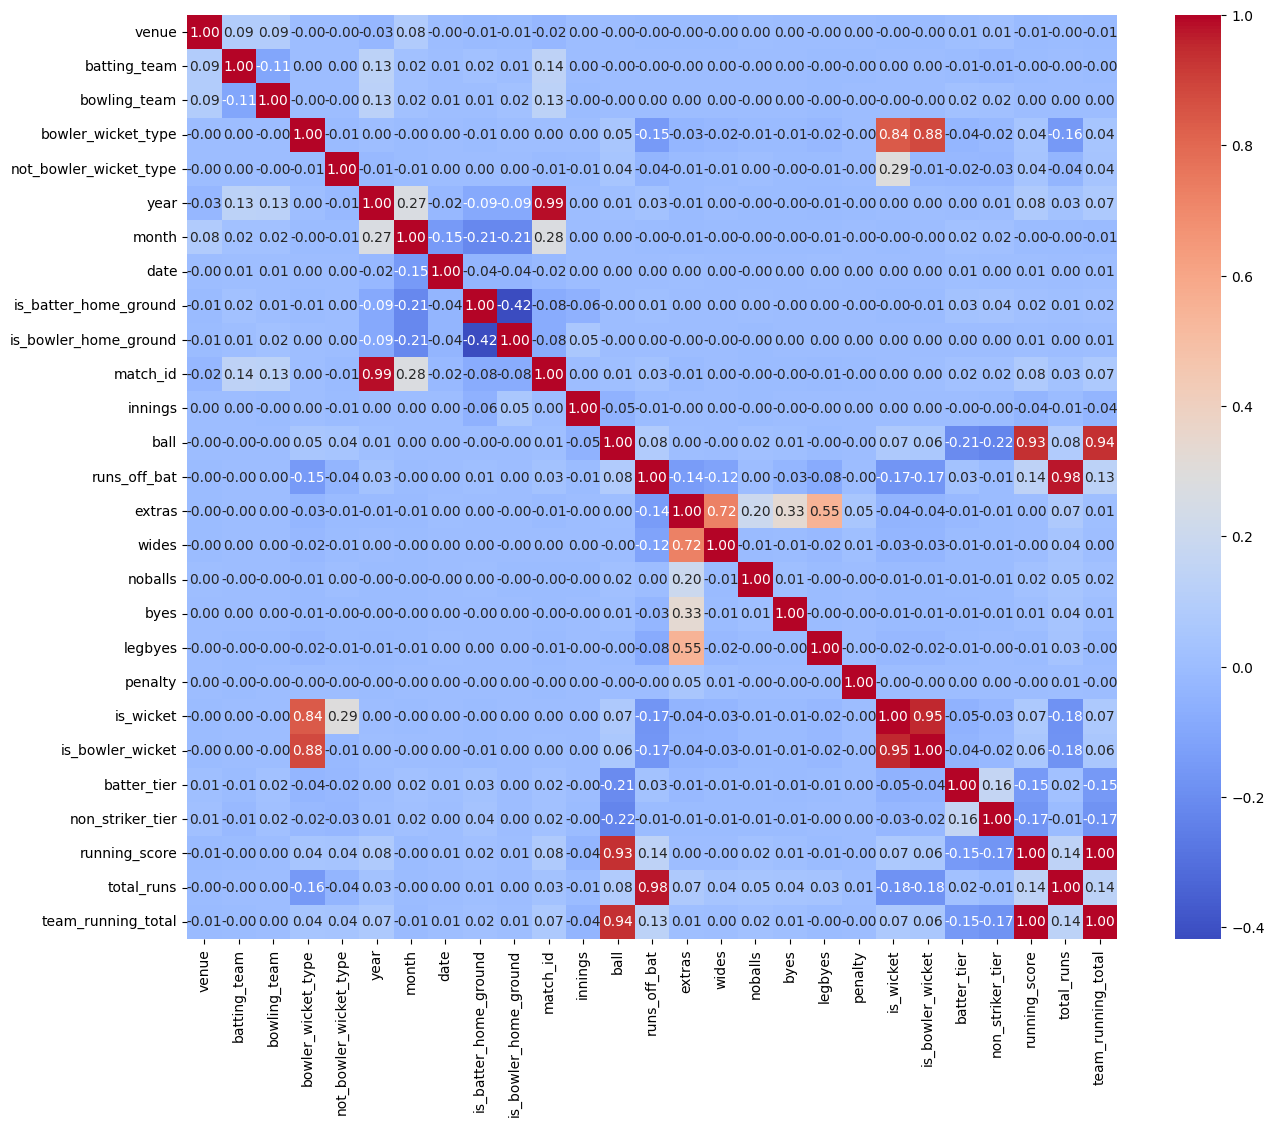

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Compute correlation
corr = df[numeric_cols].corr()

# Set figure size
plt.figure(figsize=(15, 12))  # width=15, height=12, adjust as needed

# Plot heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Show plot
plt.show()


In [ ]:
df.to_csv("semi_processed_data_2.csv")